Import all the necessary libraries

In [ ]:
import sys
assert sys.version_info >= (3, 7)

In [ ]:
import time
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

The default font sizes

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

:Very slow without a GPU, try to make sure there's one, or else issue a warning:

In [ ]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.
Go to Runtime > Change runtime and select a GPU hardware accelerator.


Download the dataset

In [ ]:
tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".",
    extract=True
)

108512/108512 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


'./datasets/ridership_extracted'

In [ ]:
path = Path("datasets/ridership_extracted/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [ ]:
# Improving the dataset

df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


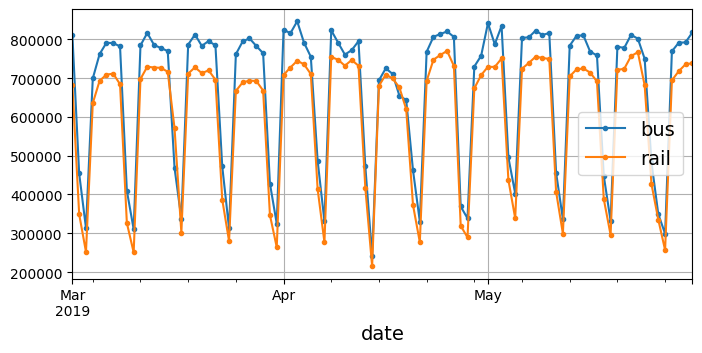

In [ ]:
df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

Mean absolute error (MAE)

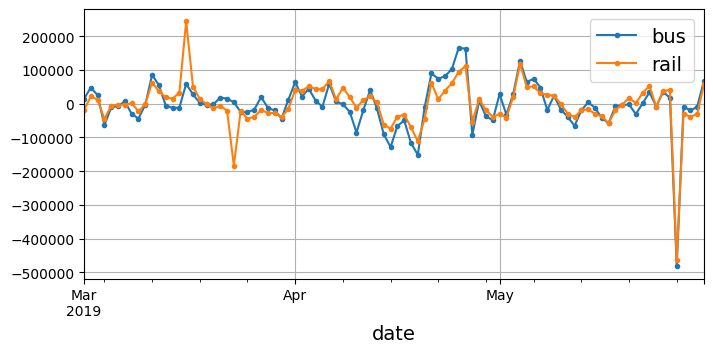

,0
bus,43915.608696
rail,42143.271739


In [ ]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
diff_7.plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

diff_7.abs().mean()



Mean absolute percentage error (MAPE):

In [ ]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

,0
bus,0.082938
rail,0.089948


Split the time series into three periods, for training, validation and testing.



In [ ]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

Default dictionary for the Recurrent Neural Networks

In [ ]:
DEFAULT_CONFIG = {
    'n_layers': 4,              # testar pelo menos 4 valores diferentes
    'n_neurons': 32,            # testar pelo menos 5 valores diferentes
    'activation': 'tanh',       # Padrão de RNNs (teste também 'relu' e 'sigmoid')
    'weight_init': 'random',    # ou 'specific'
    'init_mean': 0.0,           # Média da distribuição (se for specific)
    'init_stddev': 0.1,         # Desvio padrão (se for specific)
    'optimizer': 'adam',        # ou 'sgd'
    'learning_rate': 0.01,      # Teste 4 valores diferentes
    'batch_size': 32,           # Teste 4 valores diferentes
    'seq_length': 56,           # 8 semanas de histórico
    'n_predictions': 1,         # Quantos passos prever à frente (ou dimensão do vetor)
    'rnn_type': 'SimpleRNN',    # ou 'LSTM', 'GRU'
    'rnn_mode': 'seq2vec',      # ou 'seq2seq'
    'epochs': 30,
}

The `create dataset` function transforms raw data (arrays of numbers) into organized packages (`tf.data.Dataset`) that TensorFlow can use to train the neural network.

In [ ]:
def create_datasets(config):
    seq_length = config['seq_length']
    batch_size = config['batch_size']
    mode = config['rnn_mode']

    train_data = rail_train.astype(np.float32).to_numpy()
    valid_data = rail_valid.astype(np.float32).to_numpy()

    if mode == 'seq2vec':

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            train_data,
            targets=train_data[seq_length:],
            sequence_length=seq_length,
            batch_size=batch_size,
            shuffle=True,
            seed=42
        )

        valid_ds = tf.keras.utils.timeseries_dataset_from_array(
            valid_data,
            targets=valid_data[seq_length:],
            sequence_length=seq_length,
            batch_size=batch_size
        )

    elif mode == 'seq2seq':

        def to_windows(dataset, length):
            dataset = dataset.window(length, shift=1, drop_remainder=True)
            return dataset.flat_map(lambda window_ds: window_ds.batch(length))

        def make_seq2seq_ds(series):
            series = series.astype(np.float32)
            ds = tf.data.Dataset.from_tensor_slices(series)
            ds = to_windows(ds, seq_length + 1)
            ds = ds.map(lambda S: (S[:-1], S[1:]))
            return ds.batch(batch_size)

        train_ds = make_seq2seq_ds(train_data)
        if hasattr(train_ds, 'shuffle'): train_ds = train_ds.shuffle(1000, seed=42)
        valid_ds = make_seq2seq_ds(valid_data)

    return train_ds, valid_ds

Read the config dictionary and build the Neural Network layer by layer

In [ ]:
def build_experiment_model(config):
    layers = []
    input_shape = [None, 1]
    n_layers = config['n_layers']

    #weight initialization
    if config['weight_init'] == 'random':
        initializer = 'glorot_uniform'
    elif config['weight_init'] == 'specific':
        initializer = tf.keras.initializers.RandomNormal(
            mean=config['init_mean'],
            stddev=config['init_stddev'],
            seed=42,
        )
    else:
        initializer = config['weight_init']

    #layer stacking
    for i in range(n_layers):
        if config['rnn_mode'] == 'seq2seq':
            return_seq = True
        else:
            return_seq = (i < n_layers - 1)

        layer_class = getattr(tf.keras.layers, config['rnn_type'])

        layer_params = {
            'units': config['n_neurons'],
            'activation': config['activation'],
            'return_sequences': return_seq,
            'kernel_initializer': initializer,
        }

        if i == 0:
            layer_params['input_shape'] = input_shape

        layers.append(layer_class(**layer_params))

    #output layer
    layers.append(tf.keras.layers.Dense(config['n_predictions']))

    model = tf.keras.Sequential(layers)
    return model

Executes the complete cycle: configures data/model, trains with Early Stopping, and evaluates performance. Returns a dictionary with metrics (MAE, time) and history to generate comparative tables.

In [ ]:
def run_experiment(user_config={}):
    #mix configs
    config = DEFAULT_CONFIG.copy()
    config.update(user_config)

    print(f"\n> Config: {user_config}")

    #creates dataset and model
    train_ds, valid_ds = create_datasets(config)
    model = build_experiment_model(config)

    #optimizer
    if config['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=config['learning_rate'])
    elif config['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=config['learning_rate'], momentum=0.9)

    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

    #training
    start_time = time.time()
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=10, restore_best_weights=True) #patience 10 to have less noise

    print("  Training...", end="")
    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=config['epochs'],
        callbacks=[early_stopping],
        verbose=0 #change this to 1 to see the epochs
    )
    end_time = time.time()
    computation_time = end_time - start_time
    print("Done")

    #final evaluation
    val_loss, val_mae = model.evaluate(valid_ds, verbose=0)
    final_mae = val_mae * 1e6

    print(f"  Time: {computation_time:.2f}s | Final MAE: {final_mae:,.2f}")

    return {
        'config': config,
        'time': computation_time,
        'mae': final_mae,
        'history': history.history
    }

Define and run the tests making the changes in the following cell

In [ ]:
set_layers = [1,2,3,4]
set_neurons = [16, 32, 64, 128]
results = []

for layer in set_layers:
    for neurons in set_neurons:
        current_config = {
            'n_layers': layer,
            'n_neurons': neurons,
            'activation': 'tanh',
            'weight_init': 'random',
            'init_mean': 0.0,
            'init_stddev': 0.1,
            'optimizer': 'adam',
            'learning_rate': 0.01,
            'batch_size': 32,
            'rnn_type': 'SimpleRNN',
            'rnn_mode': 'seq2vec',
            'epochs': 30
        }

        print(f"Testing: {layer} Layer | {neurons} Neurons...")
        res = run_experiment(current_config)
        results.append(res)

Testing: 1 Layer | 16 Neurons...

> Config: {'n_layers': 1, 'n_neurons': 16, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Training...Done
  Time: 18.85s | Final MAE: 34,709.89
Testing: 1 Layer | 32 Neurons...

> Config: {'n_layers': 1, 'n_neurons': 32, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Training...Done
  Time: 7.78s | Final MAE: 43,096.27
Testing: 1 Layer | 64 Neurons...

> Config: {'n_layers': 1, 'n_neurons': 64, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}


...

  Training...Done
  Time: 23.61s | Final MAE: 34,886.80
Testing: 4 Layer | 64 Neurons...

> Config: {'n_layers': 4, 'n_neurons': 64, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Training...Done
  Time: 27.31s | Final MAE: 122,437.54
Testing: 4 Layer | 128 Neurons...

> Config: {'n_layers': 4, 'n_neurons': 128, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Training...Done
  Time: 22.23s | Final MAE: 161,336.54


Generate Final Table

In [ ]:
df_results = pd.DataFrame([{
    'Layers': r['config']['n_layers'],
    'Neurons': r['config']['n_neurons'],
    'MAE': r['mae'],
    'Tempo (s)': r['time']
} for r in results])

print("\n=== FINAL RESULTS ===")
print("\n", df_results)


=== FINAL RESULTS ===

     Layers  Neurons            MAE  Tempo (s)
0        1       16   34709.885716  18.853274
1        1       32   43096.266687   7.780178
2        1       64   40252.875537   9.984257
3        1      128  122010.096908  11.311063
4        2       16   32872.218639  15.904768
5        2       32   38270.492107  17.262161
6        2       64   31790.241599  26.823911
7        2      128  122538.968921  15.261369
8        3       16   33912.874758  19.764664
9        3       32   34973.200411  22.401469
10       3       64  122664.548457  17.968220
11       3      128  122512.757778  17.504644
12       4       16   34352.451563  30.464156
13       4       32   34886.803478  23.609622
14       4       64  122437.536716  27.306546
15       4      128  161336.541176  22.234201


GRAPHS TO SHOW THE RESULTS



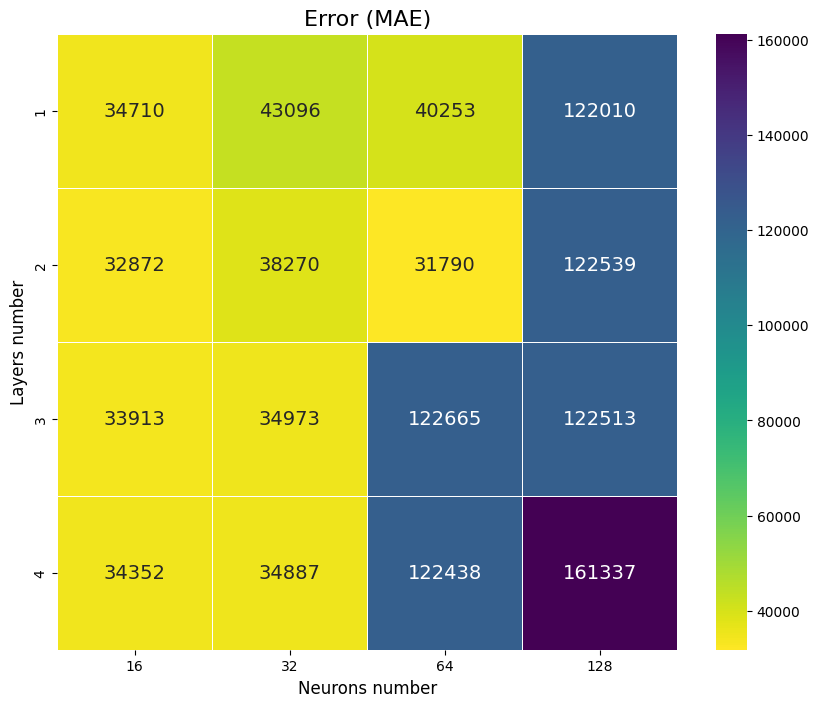

In [ ]:
import seaborn as sns

#HEATMAP for MAE error (comparing layers and neurons)
pivot_table = df_results.pivot(index="Layers", columns="Neurons", values="MAE")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="viridis_r", linewidths=.5)
plt.title("Error (MAE)", fontsize=16)
plt.xlabel("Neurons number", fontsize=12)
plt.ylabel("Layers number", fontsize=12)
plt.show()

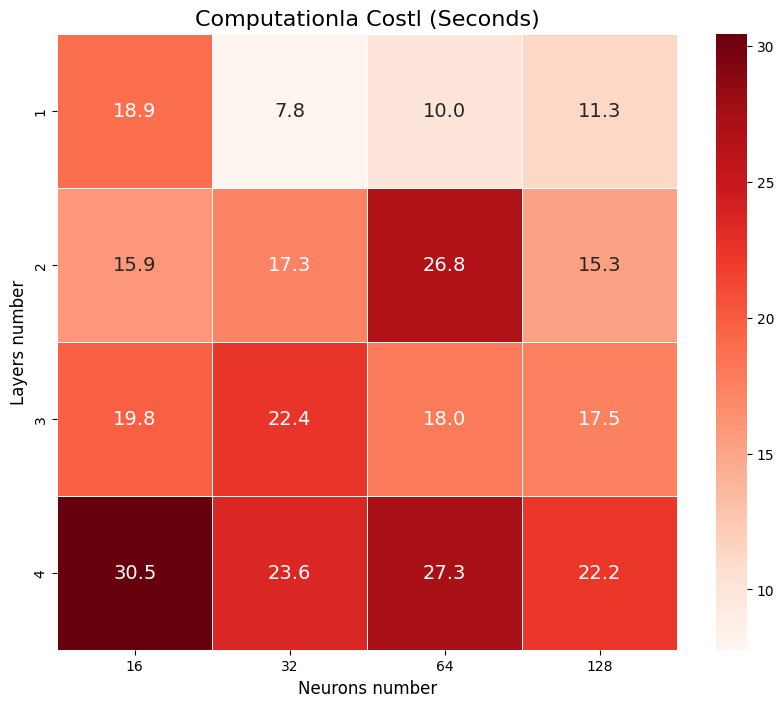

In [ ]:

#HEATMAP for Computational Cost (comparing layers and neurons)
pivot_time = df_results.pivot(index="Layers", columns="Neurons", values="Tempo (s)")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_time, annot=True, fmt=".1f", cmap="Reds", linewidths=.5)
plt.title("Computationla Costl (Seconds)", fontsize=16)
plt.xlabel("Neurons number", fontsize=12)
plt.ylabel("Layers number", fontsize=12)
plt.show()

In [ ]:
set_layers = [2]
set_neurons = [64]
results = []

for layer in set_layers:
    for neurons in set_neurons:
        current_config = {
            'n_layers': layer,
            'n_neurons': neurons,
            'activation': 'tanh',
            'weight_init': 'random',
            'init_mean': 0.0,
            'init_stddev': 0.1,
            'optimizer': 'adam',
            'learning_rate': 0.01,
            'batch_size': 32,
            'rnn_type': 'SimpleRNN',
            'rnn_mode': 'seq2vec',
            'epochs': 30
        }

        print(f"Testing: {layer} Layer | {neurons} Neurons...")
        res = run_experiment(current_config)
        results.append(res)

Testing: 2 Layer | 64 Neurons...

> Config: {'n_layers': 2, 'n_neurons': 64, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Training...Done
  Time: 16.41s | Final MAE: 38,622.36


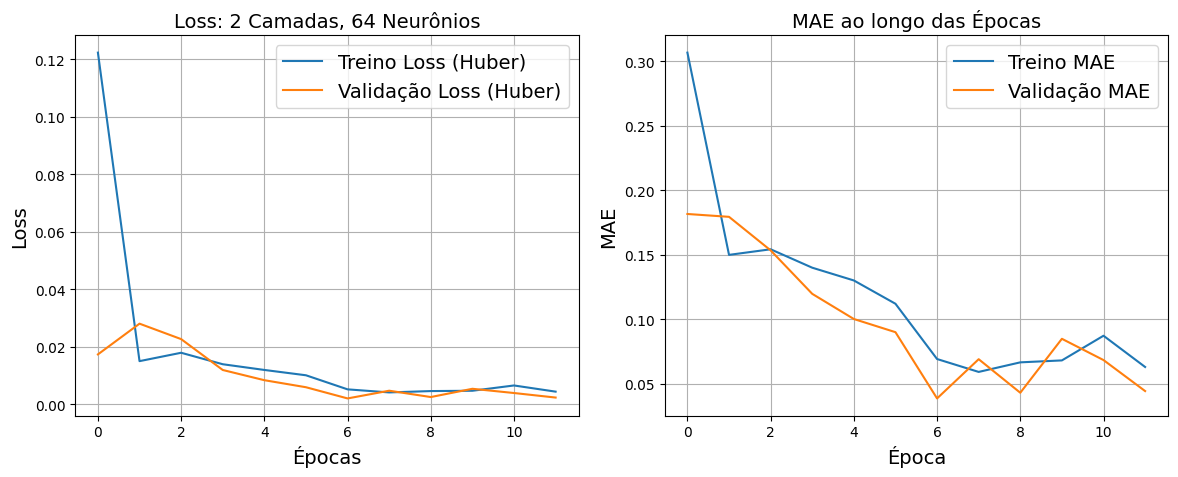

In [ ]:
# Recupera o histórico do primeiro resultado
history_data = results[0]['history']

plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: LOSS (Huber) ---
plt.subplot(1, 2, 1)
plt.plot(history_data['loss'], label='Treino Loss (Huber)')
plt.plot(history_data['val_loss'], label='Validação Loss (Huber)')
plt.title(f'Loss: {set_layers[0]} Camadas, {set_neurons[0]} Neurônios')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

#ACURÁCIA ou MAE
plt.subplot(1, 2, 2)

# Verifica qual métrica está disponível no histórico
if 'accuracy' in history_data:
    metric_key = 'accuracy'
    label_y = 'Acurácia'
else:
    # Se não tiver acurácia (comum em regressão com Huber loss), usa MAE
    metric_key = 'mae' if 'mae' in history_data else 'mean_absolute_error'
    label_y = 'MAE'

plt.plot(history_data[metric_key], label=f'Treino {label_y}')
plt.plot(history_data[f'val_{metric_key}'], label=f'Validação {label_y}')
plt.title(f'{label_y} ao longo das Épocas')
plt.xlabel('Época')
plt.ylabel(label_y)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
set_layers = [2]
set_neurons = [16]
results = []

for layer in set_layers:
    for neurons in set_neurons:
        current_config = {
            'n_layers': layer,
            'n_neurons': neurons,
            'activation': 'tanh',
            'weight_init': 'random',
            'init_mean': 0.0,
            'init_stddev': 0.1,
            'optimizer': 'adam',
            'learning_rate': 0.01,
            'batch_size': 32,
            'rnn_type': 'SimpleRNN',
            'rnn_mode': 'seq2vec',
            'epochs': 30
        }

        print(f"Testing: {layer} Layer | {neurons} Neurons...")
        res = run_experiment(current_config)
        results.append(res)

Testing: 2 Layer | 16 Neurons...

> Config: {'n_layers': 2, 'n_neurons': 16, 'activation': 'tanh', 'weight_init': 'random', 'init_mean': 0.0, 'init_stddev': 0.1, 'optimizer': 'adam', 'learning_rate': 0.01, 'batch_size': 32, 'rnn_type': 'SimpleRNN', 'rnn_mode': 'seq2vec', 'epochs': 30}
  Training...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done
  Time: 19.40s | Final MAE: 29,247.12


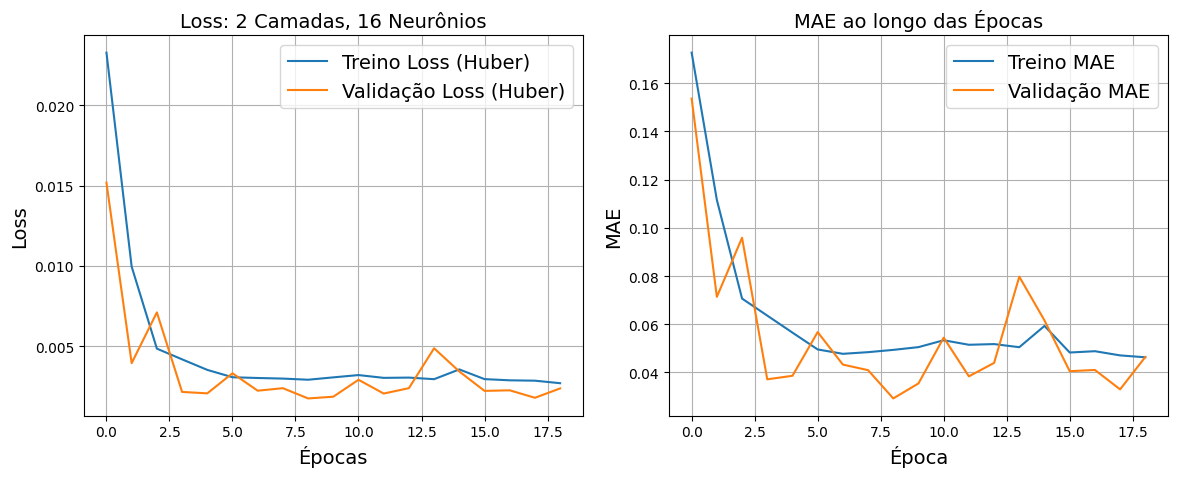

In [ ]:
# Recupera o histórico do primeiro resultado
history_data = results[0]['history']

plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: LOSS (Huber) ---
plt.subplot(1, 2, 1)
plt.plot(history_data['loss'], label='Treino Loss (Huber)')
plt.plot(history_data['val_loss'], label='Validação Loss (Huber)')
plt.title(f'Loss: {set_layers[0]} Camadas, {set_neurons[0]} Neurônios')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

#ACURÁCIA ou MAE
plt.subplot(1, 2, 2)

# Verifica qual métrica está disponível no histórico
if 'accuracy' in history_data:
    metric_key = 'accuracy'
    label_y = 'Acurácia'
else:
    # Se não tiver acurácia (comum em regressão com Huber loss), usa MAE
    metric_key = 'mae' if 'mae' in history_data else 'mean_absolute_error'
    label_y = 'MAE'

plt.plot(history_data[metric_key], label=f'Treino {label_y}')
plt.plot(history_data[f'val_{metric_key}'], label=f'Validação {label_y}')
plt.title(f'{label_y} ao longo das Épocas')
plt.xlabel('Época')
plt.ylabel(label_y)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The best model is with 2 layers and 16 neurons, it has a MAE a little bigger than the 2 layers model with 64 neuros but this model is overfitting is to complex for this dataset. In the graphic above we can see that the model has a learning rate too high, but it will be ajusted in the next modifications. for the next modifications the default model is going to be 2 layers with 16 neurons. Compare in the report the 2 results

It's strange that validation is better than training, but there are two common causes for this in Keras/TensorFlow:

Luck in Data Splitting (Most likely here): The randomly selected validation set may contain "simpler" examples to predict than the training set. Since your dataset appears to have variations, it may be that the train_test_split left the difficult cases in training.

Training Mechanics: Training loss is calculated as an average over the entire epoch. Validation loss is calculated at the end of the epoch. Because the model learned during the epoch, at the end it is "smarter" than it was at the beginning, which favors the validation metric.